In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib


In [2]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

print(df.head())
print(df.describe())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563

In [4]:
features = ['MedInc', 'AveRooms', 'HouseAge']
X = df[features]
y = df['Price']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [7]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Mean Squared Error: 0.6589
R² Score: 0.4972


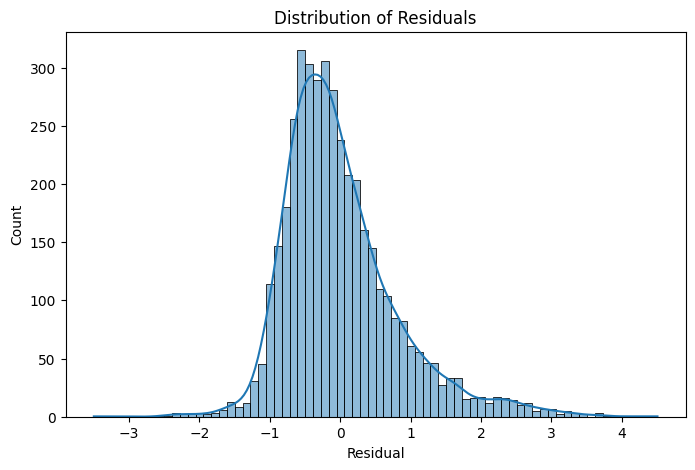

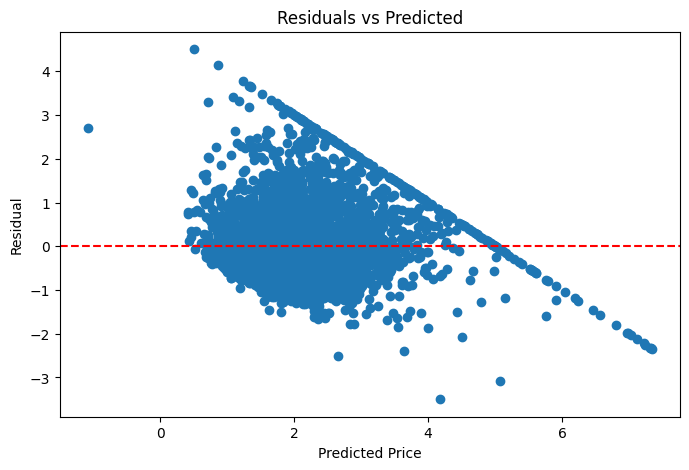

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.show()


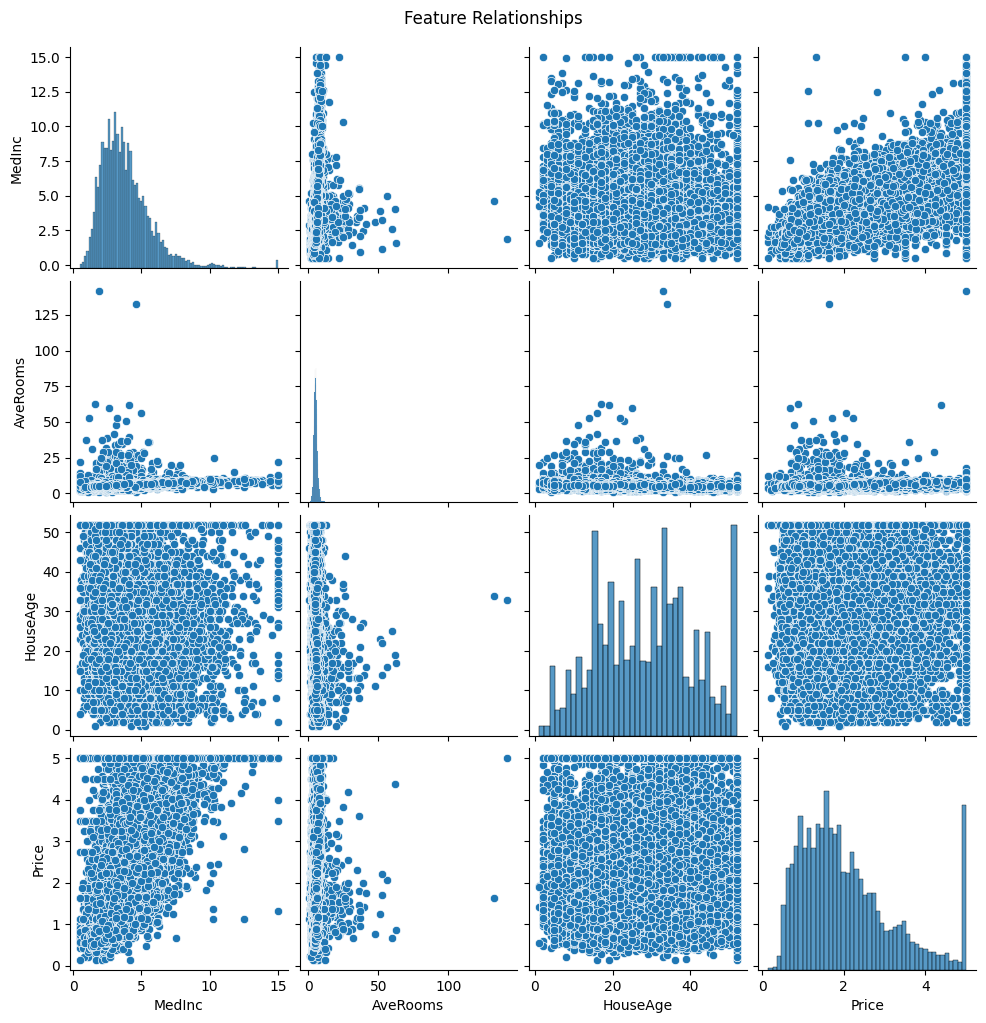

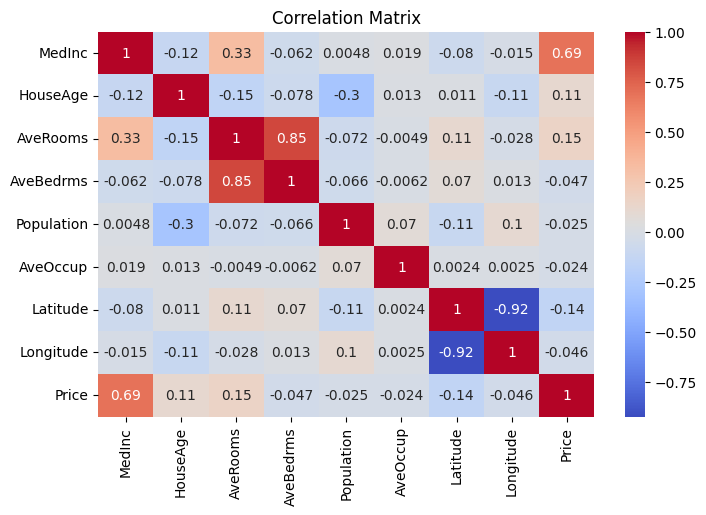

In [9]:
sns.pairplot(df[['MedInc', 'AveRooms', 'HouseAge', 'Price']])
plt.suptitle("Feature Relationships", y=1.02)
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [10]:
joblib.dump(model, 'house_price_model.joblib')
print("Model saved as house_price_model.joblib")

Model saved as house_price_model.joblib


In [12]:
# Take user input for 3 features
med_inc = float(input("Enter Median Income (MedInc): "))
avg_rooms = float(input("Enter Average Rooms (AveRooms): "))
house_age = float(input("Enter House Age (HouseAge): "))

# Prepare input for prediction
input_df = pd.DataFrame([[med_inc, avg_rooms, house_age]], columns=['MedInc', 'AveRooms', 'HouseAge'])

# Predict using the trained model
predicted_price = model.predict(input_df)[0]

print(f"\n Predicted House Price (in 100,000s USD): {predicted_price:.2f}")


Enter Median Income (MedInc): 4.5
Enter Average Rooms (AveRooms): 7.5
Enter House Age (HouseAge): 10

 Predicted House Price (in 100,000s USD): 1.98
